In [1]:
# Import library utama untuk manipulasi data dan visualisasi
import pandas as pd  # Untuk membaca dan memanipulasi data dalam format DataFrame
import numpy as np  # Untuk operasi numerik dan array
import matplotlib.pyplot as plt  # Untuk membuat grafik visualisasi
import seaborn as sns  # Library visualisasi berbasis Matplotlib yang lebih interaktif

# Import library dari Scikit-Learn untuk pemrosesan data dan pembagian dataset
from sklearn.model_selection import train_test_split  # Membagi dataset menjadi data latih dan uji
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler  
# LabelEncoder: Mengubah data kategori menjadi angka
# StandardScaler: Menstandarisasi fitur dengan mean=0 dan std=1
# MinMaxScaler: Normalisasi fitur ke dalam rentang tertentu (biasanya 0 hingga 1)

from sklearn.model_selection import GridSearchCV  # Mencari parameter terbaik dengan cross-validation

# Import model machine learning dari Scikit-Learn
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier  
# RandomForestClassifier: Model berbasis pohon keputusan
# VotingClassifier: Menggabungkan beberapa model untuk meningkatkan akurasi
# StackingClassifier: Kombinasi beberapa model yang dijadikan input untuk model meta-classifier

from sklearn.linear_model import LogisticRegression  # Model klasifikasi berbasis regresi logistik

# Import metrik evaluasi model
from sklearn.metrics import accuracy_score, classification_report  
# accuracy_score: Mengukur akurasi prediksi model
# classification_report: Menampilkan metrik evaluasi seperti presisi, recall, dan f1-score

# Import library untuk seleksi fitur
from sklearn.feature_selection import SelectKBest, chi2  
from sklearn.utils import resample
# SelectKBest: Memilih sejumlah fitur terbaik berdasarkan metode statistik
# chi2: Uji Chi-Square untuk menentukan hubungan antara fitur dan target

# Import library untuk model boosting yang lebih canggih
import xgboost as xgb  # XGBoost: Model boosting yang cepat dan efisien
import lightgbm as lgb  # LightGBM: Model boosting yang lebih ringan dan cepat dibandingkan XGBoost
from xgboost import XGBClassifier  # Model klasifikasi berbasis XGBoost
from sklearn.metrics import confusion_matrix

In [2]:
test_df = pd.read_csv('datatest.csv')

In [3]:
# Daftar nama file dataset yang akan dibaca
file_paths = ["data1.csv", "data2.csv"]

# Membaca setiap file CSV ke dalam DataFrame
dfs = [pd.read_csv(file) for file in file_paths]

# Langsung melakukan merge antara kedua dataset
final_df = dfs[1].merge(dfs[0], on='id', how='left')

# Menghapus duplikat jika diperlukan
final_df = final_df.drop_duplicates(subset='id')

# Menampilkan informasi
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59400 entries, 0 to 59399
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     59400 non-null  int64  
 1   amount_tsh             59400 non-null  float64
 2   date_recorded          59400 non-null  object 
 3   funder                 55763 non-null  object 
 4   gps_height             59400 non-null  int64  
 5   installer              55745 non-null  object 
 6   longitude              59400 non-null  float64
 7   latitude               59400 non-null  float64
 8   wpt_name               59398 non-null  object 
 9   num_private            59400 non-null  int64  
 10  basin                  59400 non-null  object 
 11  subvillage             59029 non-null  object 
 12  region                 59400 non-null  object 
 13  region_code            59400 non-null  int64  
 14  district_code          59400 non-null  int64  
 15  lg

In [4]:
final_df.head()

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,...,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,...,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,...,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,...,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,...,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional


In [5]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59400 entries, 0 to 59399
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     59400 non-null  int64  
 1   amount_tsh             59400 non-null  float64
 2   date_recorded          59400 non-null  object 
 3   funder                 55763 non-null  object 
 4   gps_height             59400 non-null  int64  
 5   installer              55745 non-null  object 
 6   longitude              59400 non-null  float64
 7   latitude               59400 non-null  float64
 8   wpt_name               59398 non-null  object 
 9   num_private            59400 non-null  int64  
 10  basin                  59400 non-null  object 
 11  subvillage             59029 non-null  object 
 12  region                 59400 non-null  object 
 13  region_code            59400 non-null  int64  
 14  district_code          59400 non-null  int64  
 15  lg

In [6]:
# Mengecek missing values
print("\nMissing Values:")
print(final_df.isnull().sum())


Missing Values:
id                           0
amount_tsh                   0
date_recorded                0
funder                    3637
gps_height                   0
installer                 3655
longitude                    0
latitude                     0
wpt_name                     2
num_private                  0
basin                        0
subvillage                 371
region                       0
region_code                  0
district_code                0
lga                          0
ward                         0
population                   0
public_meeting            3334
recorded_by                  0
scheme_management         3878
scheme_name              28810
permit                    3056
construction_year            0
extraction_type              0
extraction_type_group        0
extraction_type_class        0
management                   0
management_group             0
payment                      0
payment_type                 0
water_quality         

In [7]:
# Mengisi nilai yang hilang (NaN) dengan modus (nilai yang paling sering muncul) dari setiap kolom
final_df = final_df.fillna(final_df.mode().iloc[0])

/var/folders/dx/0gk_8r4j67b1b7pj73p7rvtw0000gn/T/ipykernel_10260/3888150344.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  final_df = final_df.fillna(final_df.mode().iloc[0])


In [8]:
final_df.isnull().sum()

id                       0
amount_tsh               0
date_recorded            0
funder                   0
gps_height               0
installer                0
longitude                0
latitude                 0
wpt_name                 0
num_private              0
basin                    0
subvillage               0
region                   0
region_code              0
district_code            0
lga                      0
ward                     0
population               0
public_meeting           0
recorded_by              0
scheme_management        0
scheme_name              0
permit                   0
construction_year        0
extraction_type          0
extraction_type_group    0
extraction_type_class    0
management               0
management_group         0
payment                  0
payment_type             0
water_quality            0
quality_group            0
quantity                 0
quantity_group           0
source                   0
source_type              0
s

In [9]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59400 entries, 0 to 59399
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     59400 non-null  int64  
 1   amount_tsh             59400 non-null  float64
 2   date_recorded          59400 non-null  object 
 3   funder                 59400 non-null  object 
 4   gps_height             59400 non-null  int64  
 5   installer              59400 non-null  object 
 6   longitude              59400 non-null  float64
 7   latitude               59400 non-null  float64
 8   wpt_name               59400 non-null  object 
 9   num_private            59400 non-null  int64  
 10  basin                  59400 non-null  object 
 11  subvillage             59400 non-null  object 
 12  region                 59400 non-null  object 
 13  region_code            59400 non-null  int64  
 14  district_code          59400 non-null  int64  
 15  lg

In [10]:
# Mengecek duplikasi
duplicates = final_df.duplicated().sum()
print(f"\nJumlah data duplikat: {duplicates}")
if duplicates > 0:
    final_df.drop_duplicates(inplace=True)


Jumlah data duplikat: 0


In [11]:
# Normalisasi fitur numerik
num_columns = final_df.select_dtypes(include=['int64', 'float64']).columns
final_df[num_columns] = StandardScaler().fit_transform(final_df[num_columns])

In [12]:
# Menampilkan beberapa baris pertama setelah preprocessing
print("\nData setelah preprocessing:")
print(final_df.head())


Data setelah preprocessing:
         id  amount_tsh date_recorded        funder  gps_height     installer  \
0  1.512933    1.895665    2011-03-14         Roman    1.041252         Roman   
1 -1.320990   -0.105970    2013-03-06       Grumeti    1.054237       GRUMETI   
2 -0.130757   -0.097630    2013-02-25  Lottery Club    0.025541  World vision   
3  1.427676   -0.105970    2013-01-28        Unicef   -0.584751        UNICEF   
4 -0.810478   -0.105970    2011-07-13   Action In A   -0.964200       Artisan   

   longitude  latitude              wpt_name  num_private  ... water_quality  \
0   0.131052 -1.408791                  none    -0.038749  ...          soft   
1   0.094610  1.207934              Zahanati    -0.038749  ...          soft   
2   0.515158  0.639751           Kwa Mahundi    -0.038749  ...          soft   
3   0.671308 -1.849720  Zahanati Ya Nanyumbu    -0.038749  ...          soft   
4  -0.448669  1.317271               Shuleni    -0.038749  ...          soft   

  q

# Statistical Description

In [14]:
# Statistik deskriptif untuk kolom numerik
stats_numeric = final_df.describe()

# Statistik deskriptif untuk kolom kategorikal
stats_categorical = final_df.describe(include=['object'])

# Menampilkan hasil
print("=== Statistik Deskriptif untuk Kolom Numerik ===")
print(stats_numeric)

print("\n=== Statistik Deskriptif untuk Kolom Kategorikal ===")
print(stats_categorical)


=== Statistik Deskriptif untuk Kolom Numerik ===
                 id    amount_tsh    gps_height     longitude      latitude  \
count  5.940000e+04  5.940000e+04  5.940000e+04  5.940000e+04  5.940000e+04   
mean   1.306250e-16 -1.578984e-17  1.710566e-17 -9.719124e-16  9.653333e-17   
std    1.000008e+00  1.000008e+00  1.000008e+00  1.000008e+00  1.000008e+00   
min   -1.730071e+00 -1.059700e-01 -1.094050e+00 -5.188895e+00 -2.017454e+00   
25%   -8.667984e-01 -1.059700e-01 -9.642001e-01 -1.503004e-01 -9.621840e-01   
50%   -2.499972e-03 -1.059700e-01 -4.318175e-01  1.265828e-01  2.323277e-01   
75%    8.642807e-01 -9.929791e-02  9.391760e-01  4.721763e-01  8.078349e-01   
max    1.730852e+00  1.166561e+02  3.032277e+00  9.543790e-01  1.936878e+00   

        num_private   region_code  district_code    population  \
count  5.940000e+04  5.940000e+04   5.940000e+04  5.940000e+04   
mean   3.827840e-18  2.464172e-17  -2.416324e-17 -2.512020e-17   
std    1.000008e+00  1.000008e+00   1.000

# Visualization

/var/folders/dx/0gk_8r4j67b1b7pj73p7rvtw0000gn/T/ipykernel_10260/762467098.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=final_df, x='status_group', palette='Set2')


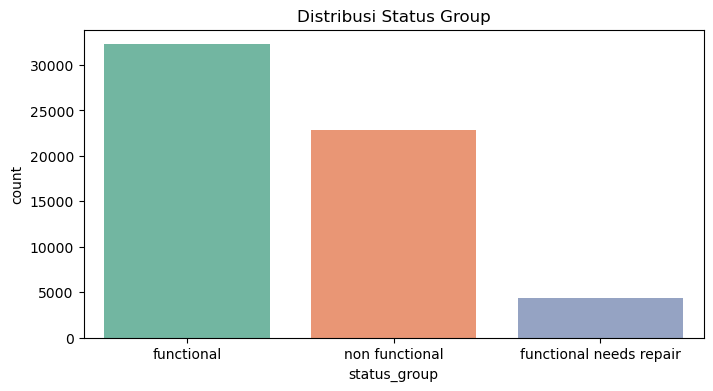

In [16]:
# Visualisasi distribusi status_group
plt.figure(figsize=(8, 4))
sns.countplot(data=final_df, x='status_group', palette='Set2')
plt.title("Distribusi Status Group")
plt.show()

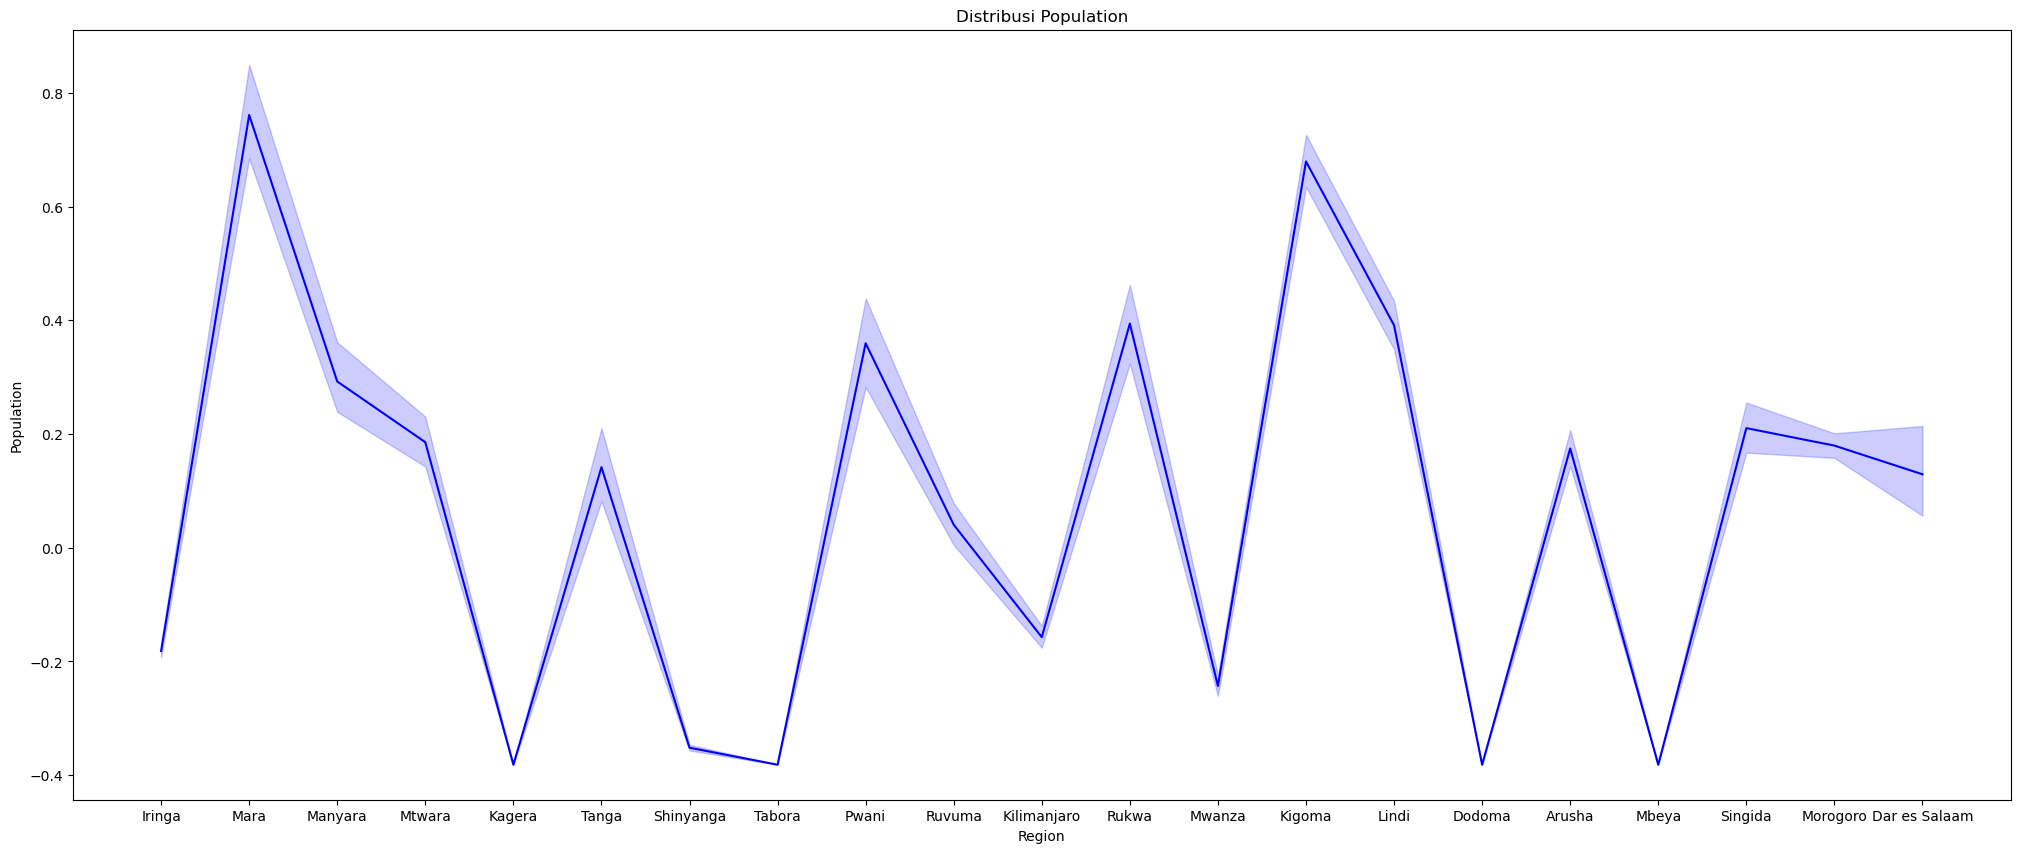

In [17]:
plt.figure(figsize=(25, 10))
sns.lineplot(data=final_df, x='region', y='population', color='blue')
plt.title("Distribusi Population")
plt.xlabel("Region")
plt.ylabel("Population")
plt.show()

/var/folders/dx/0gk_8r4j67b1b7pj73p7rvtw0000gn/T/ipykernel_10260/3675394220.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=final_df, x='water_quality', palette='Set2')


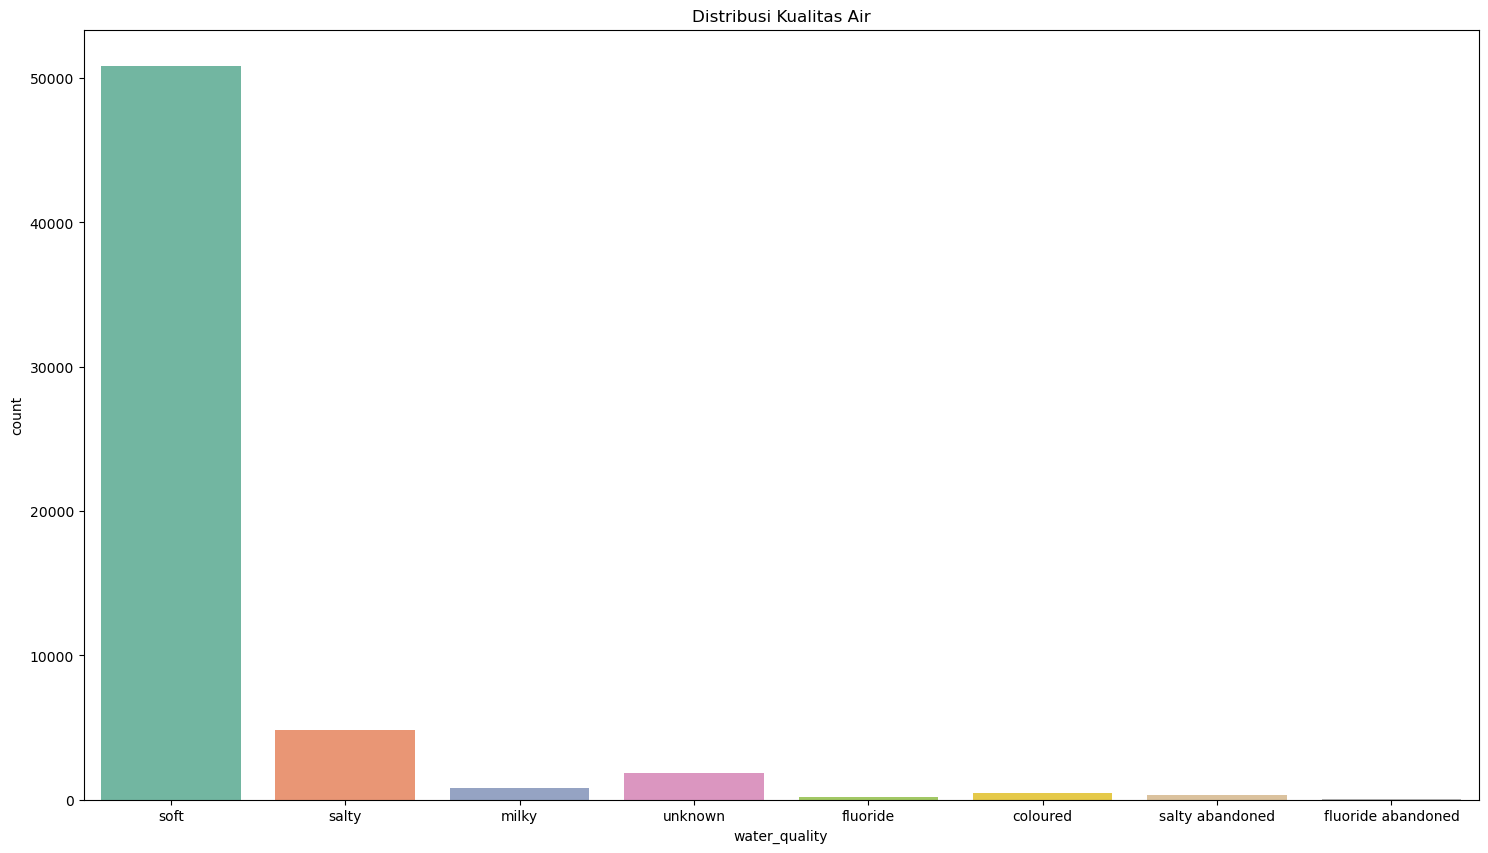

In [18]:
# Visualisasi distribusi status_group
plt.figure(figsize=(18, 10))
sns.countplot(data=final_df, x='water_quality', palette='Set2')
plt.title("Distribusi Kualitas Air")
plt.show()

/var/folders/dx/0gk_8r4j67b1b7pj73p7rvtw0000gn/T/ipykernel_10260/136630869.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=final_df, x='source', palette='Set2')


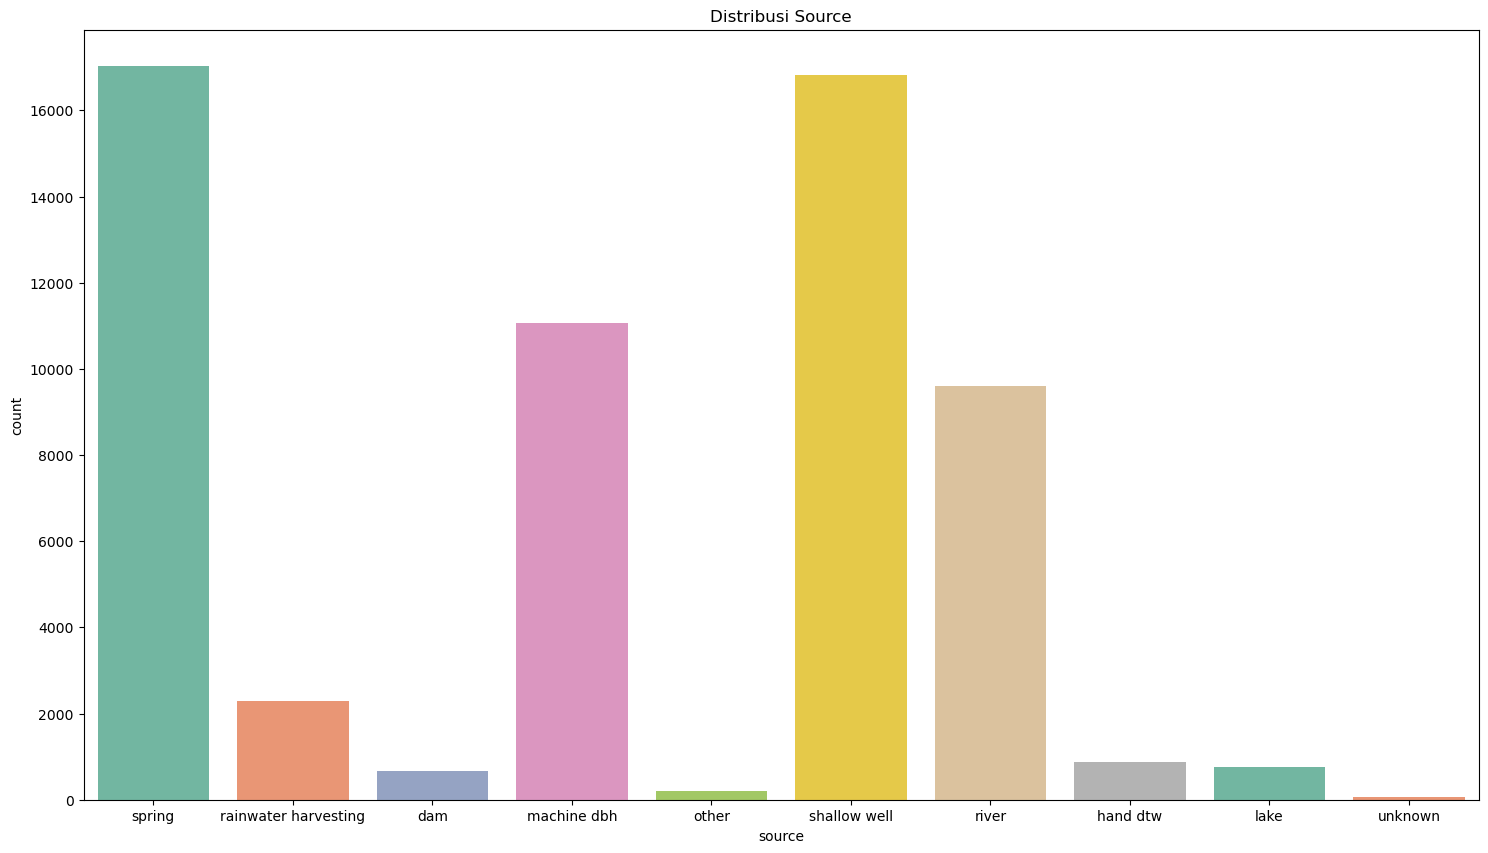

In [19]:
# Visualisasi distribusi status_group
plt.figure(figsize=(18, 10))
sns.countplot(data=final_df, x='source', palette='Set2')
plt.title("Distribusi Source")
plt.show()

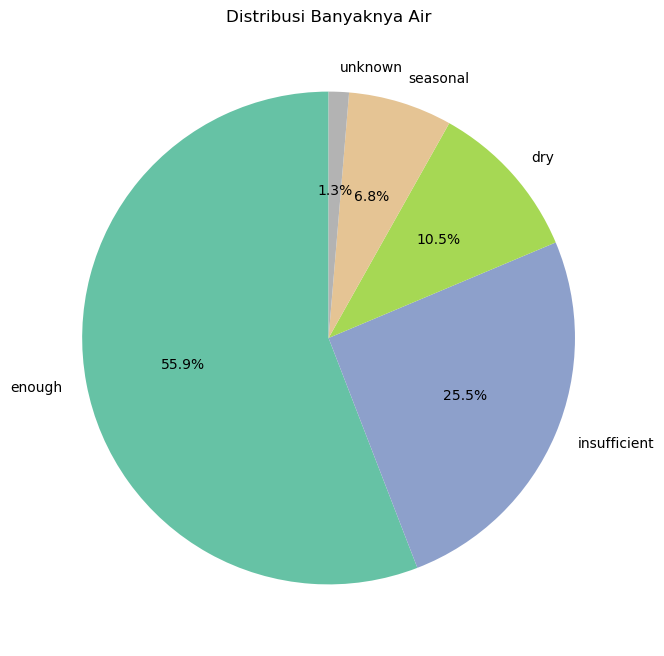

In [20]:
# Visualisasi distribusi quantity_group dengan pie chart
plt.figure(figsize=(15, 8))
final_df['quantity'].value_counts().plot.pie(autopct='%1.1f%%', cmap='Set2', startangle=90)
plt.title("Distribusi Banyaknya Air")
plt.ylabel("")
plt.show()

In [21]:
# Daftar kolom kategori yang akan dienkode
categorical_columns = ['region', 'water_quality', 'source', 'quantity', 'waterpoint_type',
                       'basin', 'management', 'payment_type']

# Dictionary untuk menyimpan encoder masing-masing kolom
label_encoders = {}

# Melakukan encoding untuk setiap kolom kategori
for col in categorical_columns:
    le = LabelEncoder()  # Inisialisasi LabelEncoder untuk kolom saat ini
    final_df[col] = le.fit_transform(final_df[col])  # Mengubah kategori menjadi angka
    label_encoders[col] = le  # Simpan encoder agar bisa digunakan kembali jika diperlukan

# Menampilkan mapping hasil encoding untuk setiap kolom
for col, le in label_encoders.items():
    print(f"\nMapping {col}:")
    for i, val in enumerate(le.classes_):  # Menampilkan pasangan nilai asli dan hasil encoding
        print(f"{i}: {val}")


Mapping region:
0: Arusha
1: Dar es Salaam
2: Dodoma
3: Iringa
4: Kagera
5: Kigoma
6: Kilimanjaro
7: Lindi
8: Manyara
9: Mara
10: Mbeya
11: Morogoro
12: Mtwara
13: Mwanza
14: Pwani
15: Rukwa
16: Ruvuma
17: Shinyanga
18: Singida
19: Tabora
20: Tanga

Mapping water_quality:
0: coloured
1: fluoride
2: fluoride abandoned
3: milky
4: salty
5: salty abandoned
6: soft
7: unknown

Mapping source:
0: dam
1: hand dtw
2: lake
3: machine dbh
4: other
5: rainwater harvesting
6: river
7: shallow well
8: spring
9: unknown

Mapping quantity:
0: dry
1: enough
2: insufficient
3: seasonal
4: unknown

Mapping waterpoint_type:
0: cattle trough
1: communal standpipe
2: communal standpipe multiple
3: dam
4: hand pump
5: improved spring
6: other

Mapping basin:
0: Internal
1: Lake Nyasa
2: Lake Rukwa
3: Lake Tanganyika
4: Lake Victoria
5: Pangani
6: Rufiji
7: Ruvuma / Southern Coast
8: Wami / Ruvu

Mapping management:
0: company
1: other
2: other - school
3: parastatal
4: private operator
5: trust
6: unknown

In [22]:
num_col = final_df.select_dtypes(include=['int64', 'float64']).columns

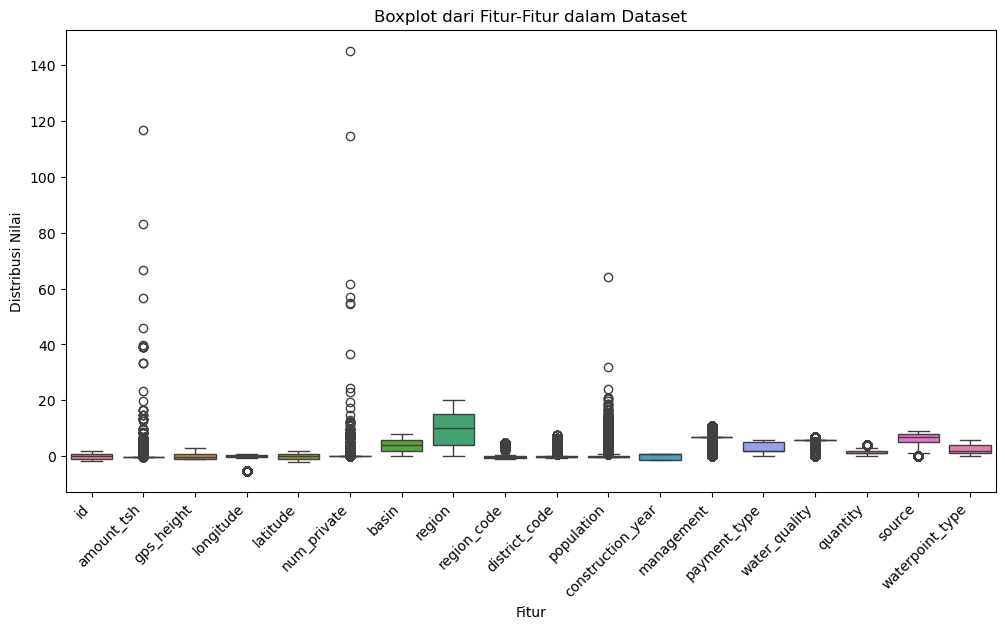

In [23]:
# Memilih hanya fitur numerik untuk boxplot
numerical_features = final_df.select_dtypes(include=['number'])

# Membuat visualisasi boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=numerical_features)
plt.xticks(ticks=range(len(numerical_features.columns)), labels=numerical_features.columns, rotation=45, ha='right')
plt.title("Boxplot dari Fitur-Fitur dalam Dataset")
plt.xlabel("Fitur")
plt.ylabel("Distribusi Nilai")
plt.show()


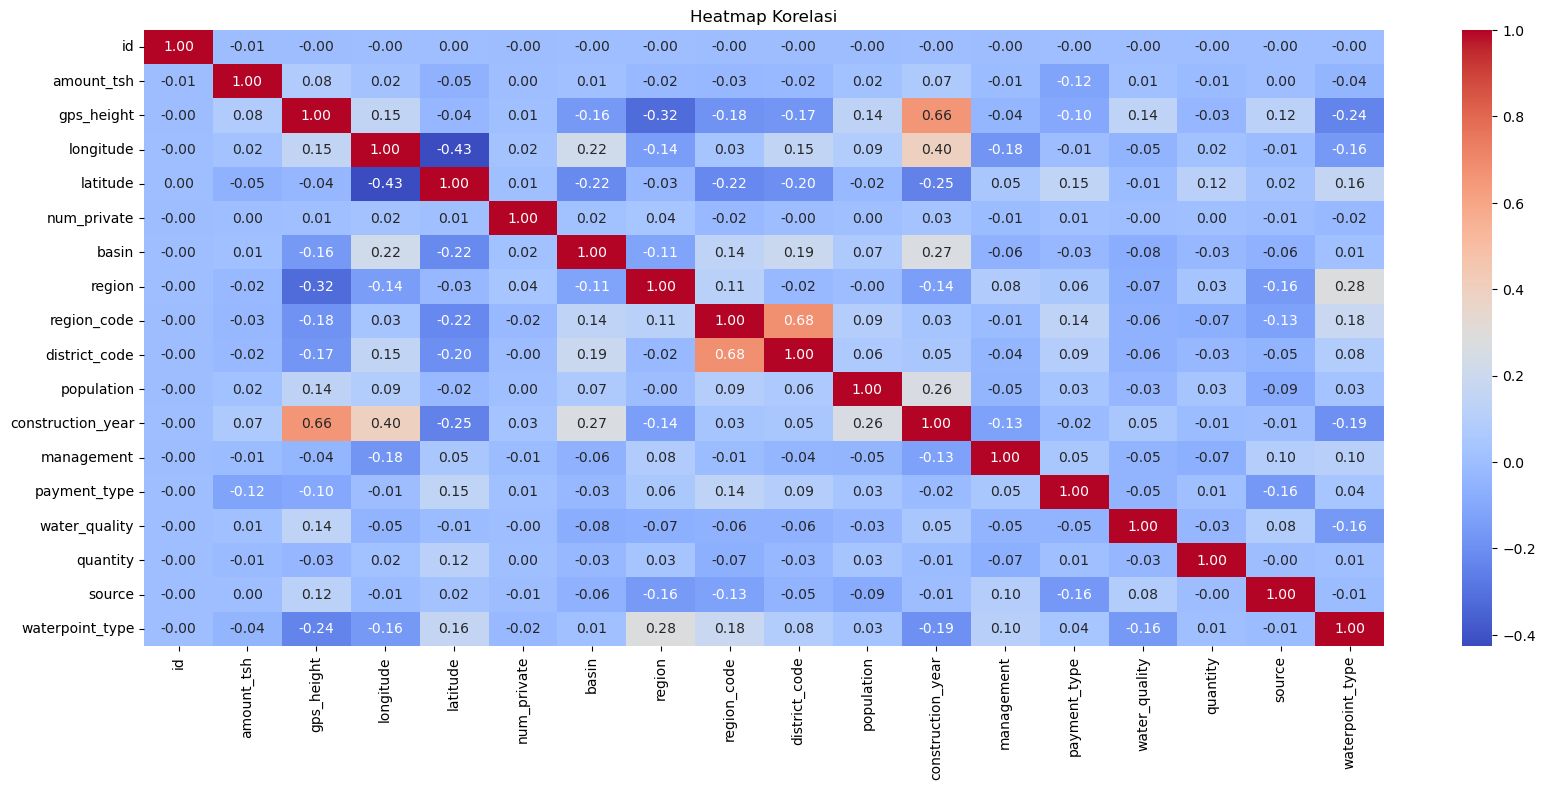

In [24]:
# Korelasi antar variabel numerik
plt.figure(figsize=(20, 8))
sns.heatmap(final_df[num_col].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Heatmap Korelasi")
plt.show()

# Data Balancing - SMOTE

In [26]:
final_df['status_group'].value_counts()

status_group
functional                 32259
non functional             22824
functional needs repair     4317
Name: count, dtype: int64

In [27]:
# Pisahkan fitur (X) dan target (y)
X = final_df.drop('status_group', axis=1)  # Hapus kolom target dari fitur
y = final_df['status_group']               # Kolom target

In [28]:
# Ambil subset data 10.000 sampel (atau kurang)
sample_df = final_df.sample(n=40000, random_state=42)

# Lanjutkan dengan langkah SMOTENC yang sama seperti sebelumnya tapi pakai sample_df


In [29]:
from sklearn.preprocessing import OrdinalEncoder
from imblearn.over_sampling import SMOTE

# Salin dataset
X_encoded = X.copy()

# Identifikasi kolom kategorikal
categorical_cols = X_encoded.select_dtypes(include=['object', 'category']).columns.tolist()

# Pastikan semua kolom kategorikal bertipe string (termasuk NaN jadi 'missing')
for col in categorical_cols:
    X_encoded[col] = X_encoded[col].astype(str).fillna('missing')

# Lanjutkan encoding
encoder = OrdinalEncoder()
X_encoded[categorical_cols] = encoder.fit_transform(X_encoded[categorical_cols])

# 3. Sekarang aman pakai SMOTE
smote = SMOTE(sampling_strategy='not majority', random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_encoded, y)

print("SMOTE sukses!")

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


SMOTE sukses!


# Modeling

In [31]:
# Random Forest With Hyperparameter Tuning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Split data hasil SMOTE untuk training & testing
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Inisialisasi model RandomForest
model = RandomForestClassifier(random_state=42)

# Latih model dasar
model.fit(X_train, y_train)

# Prediksi dengan model dasar
y_pred = model.predict(X_test)

# Evaluasi model dasar
print("Accuracy (Model dasar):", accuracy_score(y_test, y_pred))
print("Classification Report (Model dasar):")
print(classification_report(y_test, y_pred))

# Hyperparameter tuning untuk RandomForestClassifier menggunakan GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Inisialisasi GridSearchCV untuk mencari kombinasi hyperparameter terbaik
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, verbose=2, n_jobs=1)

# Latih GridSearchCV dengan data pelatihan
grid_search.fit(X_train, y_train)

# Tampilkan best hyperparameters
print(f"Best Hyperparameters from GridSearch: {grid_search.best_params_}")

# Gunakan model terbaik yang ditemukan oleh GridSearchCV
best_rf_model = grid_search.best_estimator_

# Prediksi dengan model terbaik
y_pred_best = best_rf_model.predict(X_test)

# Evaluasi model terbaik
print("Accuracy (Best Model):", accuracy_score(y_test, y_pred_best))
print("Classification Report (Best Model):")
print(classification_report(y_test, y_pred_best))


Accuracy (Model dasar): 0.8605600330646828
Classification Report (Model dasar):
                         precision    recall  f1-score   support

             functional       0.82      0.89      0.85      6540
functional needs repair       0.89      0.92      0.90      6433
         non functional       0.88      0.78      0.82      6383

               accuracy                           0.86     19356
              macro avg       0.86      0.86      0.86     19356
           weighted avg       0.86      0.86      0.86     19356

Fitting 3 folds for each of 216 candidates, totalling 648 fits
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  10.8s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  10.8s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  10.7s
[CV] END bootstrap=True, max_depth=None, m

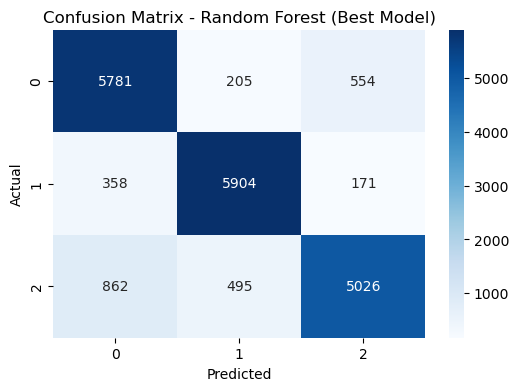

In [32]:
# Confusion Matrix (Random Forest)
cm_rf = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest (Best Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

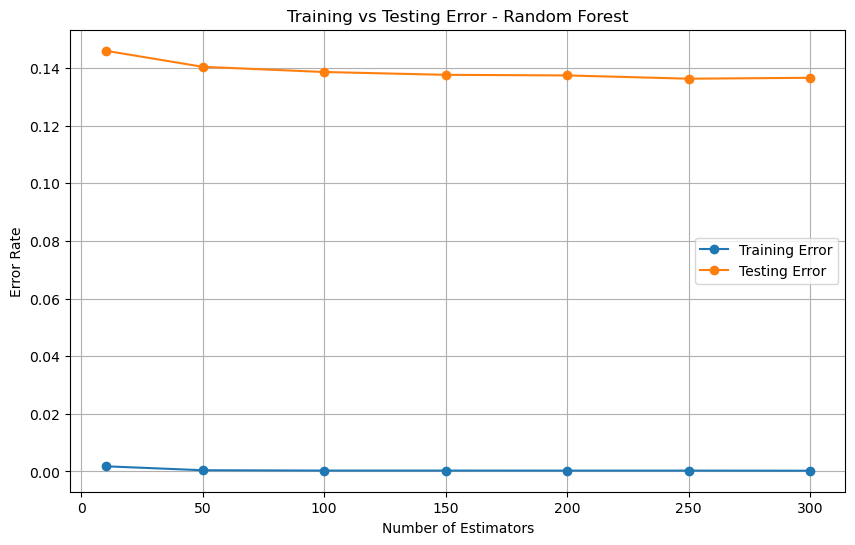

In [33]:
train_errors = [] 
test_errors = []
n_estimators_range = [10, 50, 100, 150, 200, 250, 300]

for n in n_estimators_range:
    model = RandomForestClassifier(n_estimators=n, random_state=42, **{k: v for k, v in grid_search.best_params_.items() if k != 'n_estimators'})
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_error = 1 - accuracy_score(y_train, train_pred)
    test_error = 1 - accuracy_score(y_test, test_pred)
    train_errors.append(train_error)
    test_errors.append(test_error)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, train_errors, label="Training Error", marker='o')
plt.plot(n_estimators_range, test_errors, label="Testing Error", marker='o')
plt.xlabel("Number of Estimators")
plt.ylabel("Error Rate")
plt.title("Training vs Testing Error - Random Forest")
plt.legend()
plt.grid(True)
plt.show()


In [34]:
# XG Boost Model 
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb

# Split data
X_train_xgb, X_val_xgb, y_train_xgb, y_val_xgb = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

# Encode label string ke angka
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_xgb)
y_val_encoded = le.transform(y_val_xgb)

# Convert ke DMatrix
dtrain = xgb.DMatrix(X_train_xgb, label=y_train_encoded)
dval = xgb.DMatrix(X_val_xgb, label=y_val_encoded)

# Parameter hasil tuning
params = {
    'objective': 'multi:softmax',
    'num_class': 3,
    'learning_rate': 0.1,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'eval_metric': 'mlogloss'
}

# Watchlist
watchlist = [(dtrain, 'train'), (dval, 'eval')]

# Tempat menyimpan hasil evaluasi
evals_result = {}

# Training dengan early stopping dan simpan loss ke evals_result
xgb_model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=300,
    evals=watchlist,
    early_stopping_rounds=10,
    evals_result=evals_result,  # <= Tambahkan ini
    verbose_eval=True
)
# Prediksi dan evaluasi
y_pred_encoded = xgb_model.predict(dval).astype(int)
y_pred = le.inverse_transform(y_pred_encoded)

print("Accuracy (XGBoost with early stopping):", accuracy_score(y_val_xgb, y_pred))
print("Classification Report:")
print(classification_report(y_val_xgb, y_pred))

import pickle
# Simpan model XGBoost
with open('xgboost_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)


[0]	train-mlogloss:1.04342	eval-mlogloss:1.04382
[1]	train-mlogloss:0.99801	eval-mlogloss:0.99899
[2]	train-mlogloss:0.95571	eval-mlogloss:0.95679
[3]	train-mlogloss:0.92049	eval-mlogloss:0.92147
[4]	train-mlogloss:0.88894	eval-mlogloss:0.89003
[5]	train-mlogloss:0.86150	eval-mlogloss:0.86272
[6]	train-mlogloss:0.83506	eval-mlogloss:0.83643
[7]	train-mlogloss:0.81206	eval-mlogloss:0.81341
[8]	train-mlogloss:0.79148	eval-mlogloss:0.79302
[9]	train-mlogloss:0.77263	eval-mlogloss:0.77422
[10]	train-mlogloss:0.75561	eval-mlogloss:0.75741
[11]	train-mlogloss:0.74032	eval-mlogloss:0.74243
[12]	train-mlogloss:0.72591	eval-mlogloss:0.72817
[13]	train-mlogloss:0.71296	eval-mlogloss:0.71525
[14]	train-mlogloss:0.70019	eval-mlogloss:0.70261
[15]	train-mlogloss:0.68936	eval-mlogloss:0.69198
[16]	train-mlogloss:0.67900	eval-mlogloss:0.68185
[17]	train-mlogloss:0.66958	eval-mlogloss:0.67239
[18]	train-mlogloss:0.66035	eval-mlogloss:0.66317
[19]	train-mlogloss:0.65118	eval-mlogloss:0.65430
[20]	train

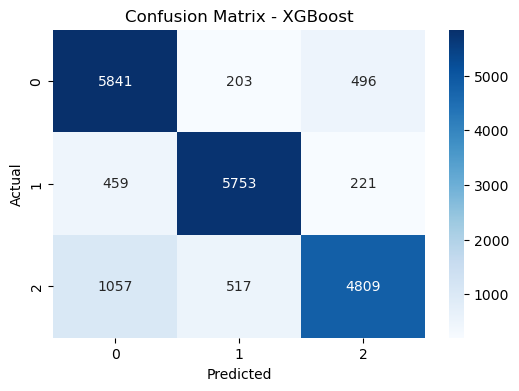

In [35]:
# Confusion Matrix (XGBoost)
cm_xgb = confusion_matrix(y_val_xgb, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

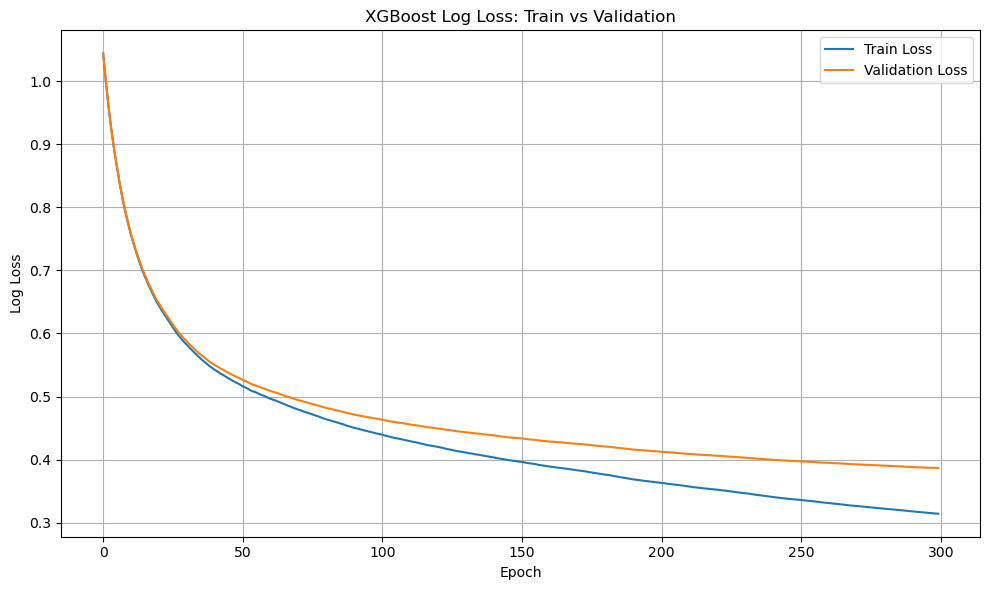

In [36]:
import matplotlib.pyplot as plt

# Ambil jumlah epoch
epochs = len(evals_result['train']['mlogloss'])
x_axis = range(epochs)

# Plot log loss
plt.figure(figsize=(10, 6))
plt.plot(x_axis, evals_result['train']['mlogloss'], label='Train Loss')
plt.plot(x_axis, evals_result['eval']['mlogloss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.title('XGBoost Log Loss: Train vs Validation')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [37]:
import lightgbm as lgb
from lightgbm import early_stopping, log_evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Split data
X_train_lgb, X_val_lgb, y_train_lgb, y_val_lgb = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

# Encode target label
le_lgb = LabelEncoder()
y_train_encoded_lgb = le_lgb.fit_transform(y_train_lgb)
y_val_encoded_lgb = le_lgb.transform(y_val_lgb)

# Inisialisasi model
lgbm_model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=3,
    learning_rate=0.1,
    max_depth=6,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='multi_logloss'
)

# Latih model dan simpan log evaluasi
lgbm_model.fit(
    X_train_lgb,
    y_train_encoded_lgb,
    eval_set=[(X_train_lgb, y_train_encoded_lgb), (X_val_lgb, y_val_encoded_lgb)],
    eval_names=['train', 'validation'],
    callbacks=[
        early_stopping(stopping_rounds=10),
        log_evaluation(period=10)
    ]
)

# Prediksi
y_pred_encoded_lgb = lgbm_model.predict(X_val_lgb)
y_pred_lgb = le_lgb.inverse_transform(y_pred_encoded_lgb)

# Evaluasi
print("Accuracy (LightGBM):", accuracy_score(y_val_lgb, y_pred_lgb))
print("Classification Report:")
print(classification_report(y_val_lgb, y_pred_lgb))


[LightGBM] [Warning] Unknown parameter: eval_metric
[LightGBM] [Warning] Unknown parameter: eval_metric
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004876 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7461
[LightGBM] [Info] Number of data points in the train set: 77421, number of used features: 39
[LightGBM] [Warning] Unknown parameter: eval_metric
[LightGBM] [Info] Start training from score -1.102028
[LightGBM] [Info] Start training from score -1.097876
[LightGBM] [Info] Start training from score -1.095942
Training until validation scores don't improve for 10 rounds
[10]	train's multi_logloss: 0.727116	validation's multi_logloss: 0.727887
[20]	train's multi_logloss: 0.615619	validation's multi_logloss: 0.616989
[30]	train's multi_logloss: 0.561334	validation's multi_logloss: 0.56429
[40]	train's multi_logloss: 0.525798	validation

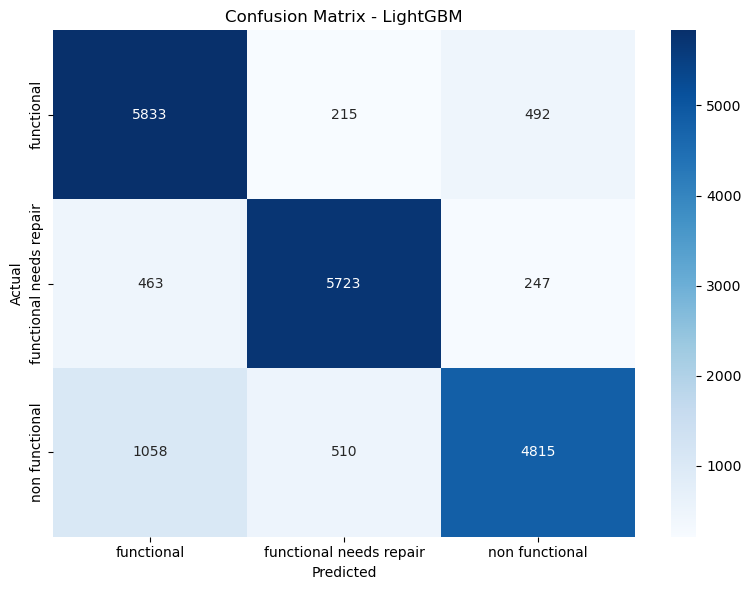

In [38]:
# Confusion Matrix
cm = confusion_matrix(y_val_lgb, y_pred_lgb, labels=le_lgb.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_lgb.classes_, yticklabels=le_lgb.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - LightGBM')
plt.tight_layout()
plt.show()


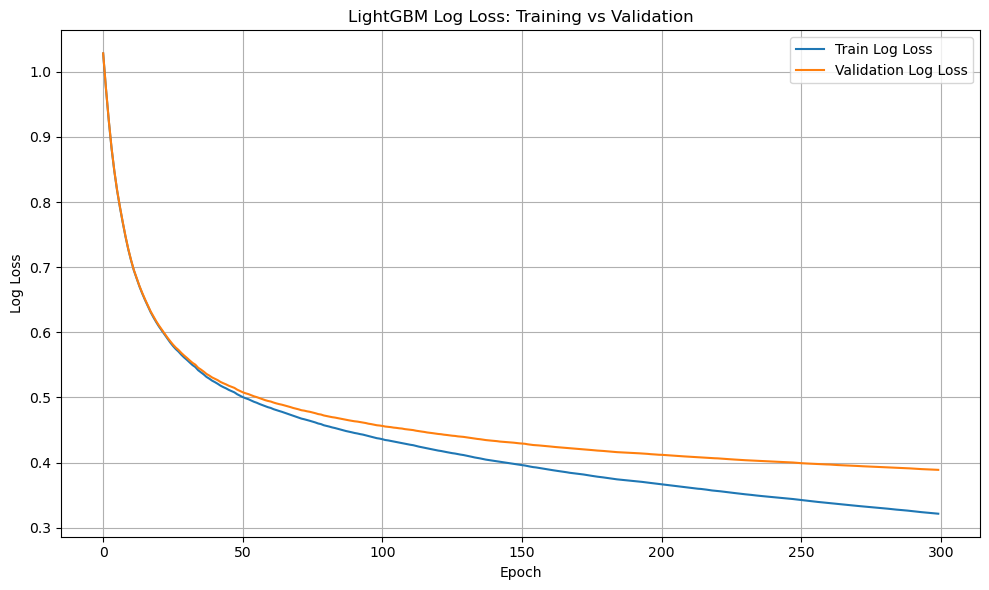

In [39]:
# Plot Log Loss
evals_result = lgbm_model.evals_result_
epochs = range(len(evals_result['train']['multi_logloss']))

plt.figure(figsize=(10, 6))
plt.plot(epochs, evals_result['train']['multi_logloss'], label='Train Log Loss')
plt.plot(epochs, evals_result['validation']['multi_logloss'], label='Validation Log Loss')
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.title('LightGBM Log Loss: Training vs Validation')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import xgboost as xgb
import pickle

# Load model
with open("xgboost_model.pkl", "rb") as f:
    model = pickle.load(f)

# Load data
data_test = pd.read_csv("datatest.csv")

data_test = data_test.fillna(data_test.mode().iloc[0])

# Kolom yang dibutuhkan
expected_features = [
    'id', 'amount_tsh', 'date_recorded', 'funder', 'gps_height', 'installer',
    'longitude', 'latitude', 'wpt_name', 'num_private', 'basin', 'subvillage',
    'region', 'region_code', 'district_code', 'lga', 'ward', 'population',
    'public_meeting', 'recorded_by', 'scheme_management', 'scheme_name',
    'permit', 'construction_year', 'extraction_type', 'extraction_type_group',
    'extraction_type_class', 'management', 'management_group', 'payment',
    'payment_type', 'water_quality', 'quality_group', 'quantity',
    'quantity_group', 'source', 'source_type', 'source_class', 'waterpoint_type',
    'waterpoint_type_group'
]

# Cek kolom yang hilang
missing_cols = [col for col in expected_features if col not in data_test.columns]
if missing_cols:
    print(f"🔴 Kolom berikut hilang dari datatest.csv: {missing_cols}")
    # Tambahkan kolom dummy (kosong atau nilai default)
    for col in missing_cols:
        data_test[col] = None  # atau data_test[col] = 0 / "" tergantung jenis datanya

# Susun ulang kolom sesuai urutan model
X_test = data_test[expected_features].copy()

# Konversi kategorikal ke category
for col in X_test.select_dtypes(include='object').columns:
    X_test[col] = X_test[col].astype('category')

# Ubah jadi DMatrix
dmatrix = xgb.DMatrix(X_test, enable_categorical=True)

# Prediksi
y_pred = model.predict(dmatrix)
data_test["status_group"] = y_pred

# Simpan
data_test.to_csv("hasil_prediksi_fix.csv", index=False)